In [18]:
!pip install tensorflow
!pip install tensorflow-hub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [19]:
df = pd.read_csv('/content/spam (1).csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [20]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df =df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(df['Text'], df['label_enc'], test_size=0.2, random_state=42)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()


In [22]:
print(X_train)

1978    Reply to win ÃÂ£100 weekly! Where will the 20...
3989    Hello. Sort of out in town already. That . So ...
3935     How come guoyang go n tell her? Then u told her?
4078    Hey sathya till now we dint meet not even a si...
4086    Orange brings you ringtones from all time Char...
                              ...                        
3772    Hi, wlcome back, did wonder if you got eaten b...
5191                               Sorry, I'll call later
5226        Prabha..i'm soryda..realy..frm heart i'm sory
5390                           Nt joking seriously i told
860               Did he just say somebody is named tampa
Name: Text, Length: 4457, dtype: object


In [23]:
print(X_train_np)

['Reply to win Ã\x82Â£100 weekly! Where will the 2006 FIFA World Cup be held? Send STOP to 87239 to end service'
 'Hello. Sort of out in town already. That . So dont rush home, I am eating nachos. Will let you know eta.'
 'How come guoyang go n tell her? Then u told her?' ...
 "Prabha..i'm soryda..realy..frm heart i'm sory"
 'Nt joking seriously i told' 'Did he just say somebody is named tampa']


In [24]:
avg_words_len = round(sum([len(i.split()) for i in df['Text']])) / len(df['Text'])
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 15.584170854271356
Approximate vocabulary size: 15686


In [25]:
def compile_and_fit(model, epochs=5):
  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  history = model.fit(
      X_train_np,
      y_train_np,
      epochs=epochs,
      validation_data=(X_test_np, y_test_np)
  )
  return history

def get_metrics(model, X, y):
  y_preds = np.round(model.predict(X))
  return{
      'accuracy': accuracy_score(y, y_preds),
      'precision': precision_score(y, y_preds),
      'recall': recall_score(y, y_pred),
      'f1-score': f1_score(y, y_preds)
  }

In [26]:
from tensorflow.keras.layers import TextVectorization
text_vec =TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    ngrams=None,
    output_mode='int',
    output_sequence_length=None,
)

In [27]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
text_vec.adapt(X_train_np) # Adapt the TextVectorization layer to the training data
X = text_vec(input_layer)
X = layers.Embedding(input_dim=total_words_length, output_dim=128)(X)
X = layers.GlobalAveragePooling1D()(X)
X = layers.Dense(32, activation='relu')(X)
output_layer = layers.Dense(1, activation='sigmoid')(X)

model_1=keras.Model(input_layer, output_layer, name='Dense_Model')
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8616 - loss: 0.3472 - val_accuracy: 0.8709 - val_loss: 0.3001
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9237 - loss: 0.2079 - val_accuracy: 0.9552 - val_loss: 0.1230
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9715 - loss: 0.0939 - val_accuracy: 0.9749 - val_loss: 0.0797
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9818 - loss: 0.0616 - val_accuracy: 0.9821 - val_loss: 0.0665
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9861 - loss: 0.0474 - val_accuracy: 0.9803 - val_loss: 0.0611


In [28]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
X = text_vec(input_layer)
X = layers.Embedding(input_dim=total_words_length, output_dim=128)(X)
X = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(X)
X = layers.Bidirectional(layers.LSTM(64))(X)
X = layers.Flatten()(X)
X = layers.Dropout(0.1)(X)
X = layers.Dense(32, activation='relu')(X)
output_layer = layers.Dense(1, activation='sigmoid')(X)

model_2 = keras.Model(input_layer, output_layer, name='LSTM_Model')
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.9390 - loss: 0.1727 - val_accuracy: 0.9803 - val_loss: 0.0663
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9921 - loss: 0.0333 - val_accuracy: 0.9830 - val_loss: 0.0546
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9980 - loss: 0.0093 - val_accuracy: 0.9883 - val_loss: 0.0570
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9978 - loss: 0.0080 - val_accuracy: 0.9857 - val_loss: 0.0860
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9857 - val_loss: 0.0744


In [29]:
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers

use_layer = hub.KerasLayer( "https://tfhub.dev/google/universal-sentence-encoder/4",
                           trainable=False,
                            name='USE')
input_layer = layers.Input(shape=[], dtype=tf.string)
# Wrap the hub_layer application in a Lambda layer to help with tf.function tracing
embedding = layers.Lambda(lambda x: use_layer(x), output_shape=(512,))(input_layer)
X = layers.Dense(32, activation='relu')(embedding) # Use 'embedding' as input
output_layer = layers.Dense(1, activation='sigmoid')(X)

model_3 = keras.Model(input_layer, output_layer, name='USE_Model')
history_3 = compile_and_fit(model_3)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9246 - loss: 0.3560 - val_accuracy: 0.9686 - val_loss: 0.1487
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9758 - loss: 0.1022 - val_accuracy: 0.9758 - val_loss: 0.0828
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9834 - loss: 0.0659 - val_accuracy: 0.9830 - val_loss: 0.0659
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9856 - loss: 0.0522 - val_accuracy: 0.9839 - val_loss: 0.0585
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9874 - loss: 0.0444 - val_accuracy: 0.9839 - val_loss: 0.0544


In [32]:
from sklearn.metrics import f1_score
def compile_and_fit(model, epochs=5):
  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  history = model.fit(
      X_train_np,
      y_train_np,
      epochs=epochs,
      validation_data=(X_test_np, y_test_np)
  )
  return history

def get_metrics(model, X, y):
  y_preds = np.round(model.predict(X))
  return{
      'accuracy': accuracy_score(y, y_preds),
      'precision': precision_score(y, y_preds),
      'recall': recall_score(y, y_preds),
      'f1-score': f1_score(y, y_preds)
  }

results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'USE': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Performance Table:
                 accuracy  precision    recall  f1-score
Dense Embedding  0.980269   0.963504  0.885906  0.923077
Bi-LSTM          0.985650   0.965035  0.926174  0.945205
USE              0.983857   0.958042  0.919463  0.938356


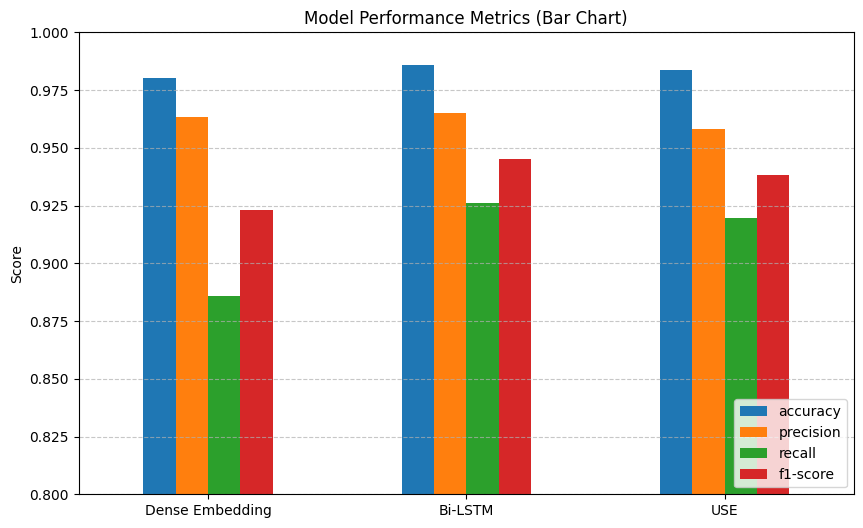

In [33]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

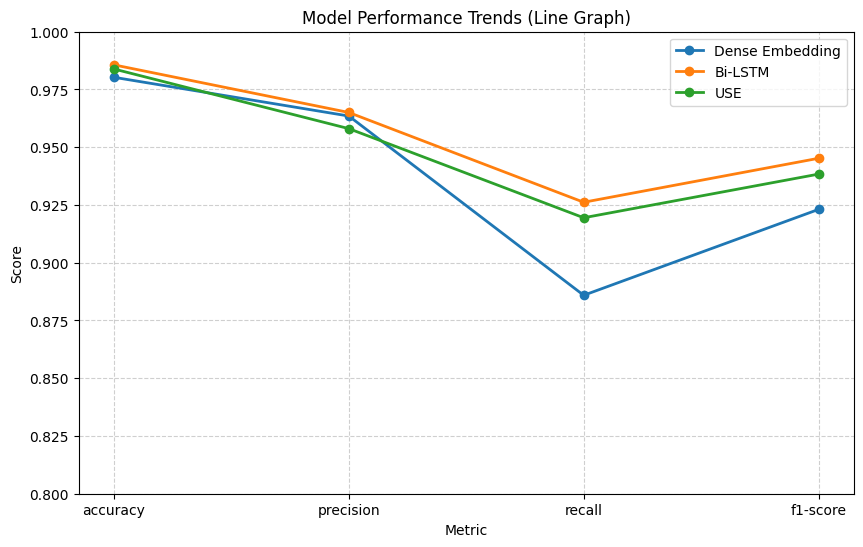

In [39]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()